In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange

# from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results, save_gif
from model import get_generator_model, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import TRAIN_PATHS, TEST_PATHS

2023-10-18 16:18:46.351700: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-18 16:18:46.378872: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-10-18 16:18:46.378901: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-10-18 16:18:46.378927: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-18 16:18:46.384346: I tensorflow/core/platform/cpu_feature_g

In [2]:
tf.__version__

'2.14.0-rc1'

In [3]:
TRAIN = True
TEST = True
TEST_VIDEO = False
PLOT = False
SAVE_GIFS = False

COHERENCE_LOSS = l1_loss
TARGET_PREDICTED_LOSS = l1_loss
LANDMARKS_LOSS = pairwise_loss
LANDMARKS_COHERENCE_LOSS = pairwise_loss
INTERPOLATION_FRAMES_LOSS = l1_loss
INTERPOLATION_LANDMARKS_LOSS = None

# Dimensions
r = 256
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68
BATCH_SIZE = 10
STEPS = 100000
STEPS = STEPS // BATCH_SIZE
SAVING_EACH_STEPS = 50
DISPLAY_EACH_STEPS = 15
N_TESTING_FRAMES = 42000

LAMBDA_TARGET_PREDICTED_LOSS = 1000
LAMBDA_COHERENCE_LOSS = 200
LAMBDA_LANDMARKS_LOSS = 100
LAMBDA_LANDMARKS_COHERENCE_LOSS = 10
LAMBDA_PERCEPTUAL_LOSS = 100
LAMBDA_INTERPOLATION_FRAMES_LOSS = 100
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'
OUPUT_PATH  = APP_PATH / 'output'

default_dimension = "mug128"

In [4]:
id_string = f"b{BATCH_SIZE}_r{r}_"
if TARGET_PREDICTED_LOSS:
    id_string += f"f1_{TARGET_PREDICTED_LOSS.__name__}_{LAMBDA_TARGET_PREDICTED_LOSS}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA_COHERENCE_LOSS}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LAMBDA_PERCEPTUAL_LOSS:
    id_string += f"_f5_perceptual_{LAMBDA_PERCEPTUAL_LOSS}"
if INTERPOLATION_FRAMES_LOSS:
    id_string += f"_f6_{INTERPOLATION_FRAMES_LOSS.__name__}_{LAMBDA_INTERPOLATION_FRAMES_LOSS}"
if INTERPOLATION_LANDMARKS_LOSS:
    id_string += f"_f7_{INTERPOLATION_LANDMARKS_LOSS.__name__}_{LAMBDA_INTERPOLATION_LANDMARKS_LOSS}"
id_string


'b5_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100'

In [5]:
OUTPUT_MEDIA_FOLDER = OUPUT_PATH / id_string / 'media'
OUTPUT_MEDIA_FOLDER.mkdir(parents=True, exist_ok=True)

In [6]:
log_dir = OUTPUT_MEDIA_FOLDER / "logs/"
date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_file = log_dir / "fit" / date_str

## Load the dataset

In [7]:
train_paths = TRAIN_PATHS
test_paths = TEST_PATHS

In [8]:
def replace_in_path(paths, default_dimension, new_dimension):
    return np.array([p.replace(default_dimension,new_dimension) for p in paths])


In [9]:
train_paths = replace_in_path(train_paths, default_dimension, f"mug{r}")
test_paths = replace_in_path(test_paths, default_dimension, f"mug{r}")

2023-10-18 16:18:50.599495: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-10-18 16:18:50.602824: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-10-18 16:18:50.602921: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

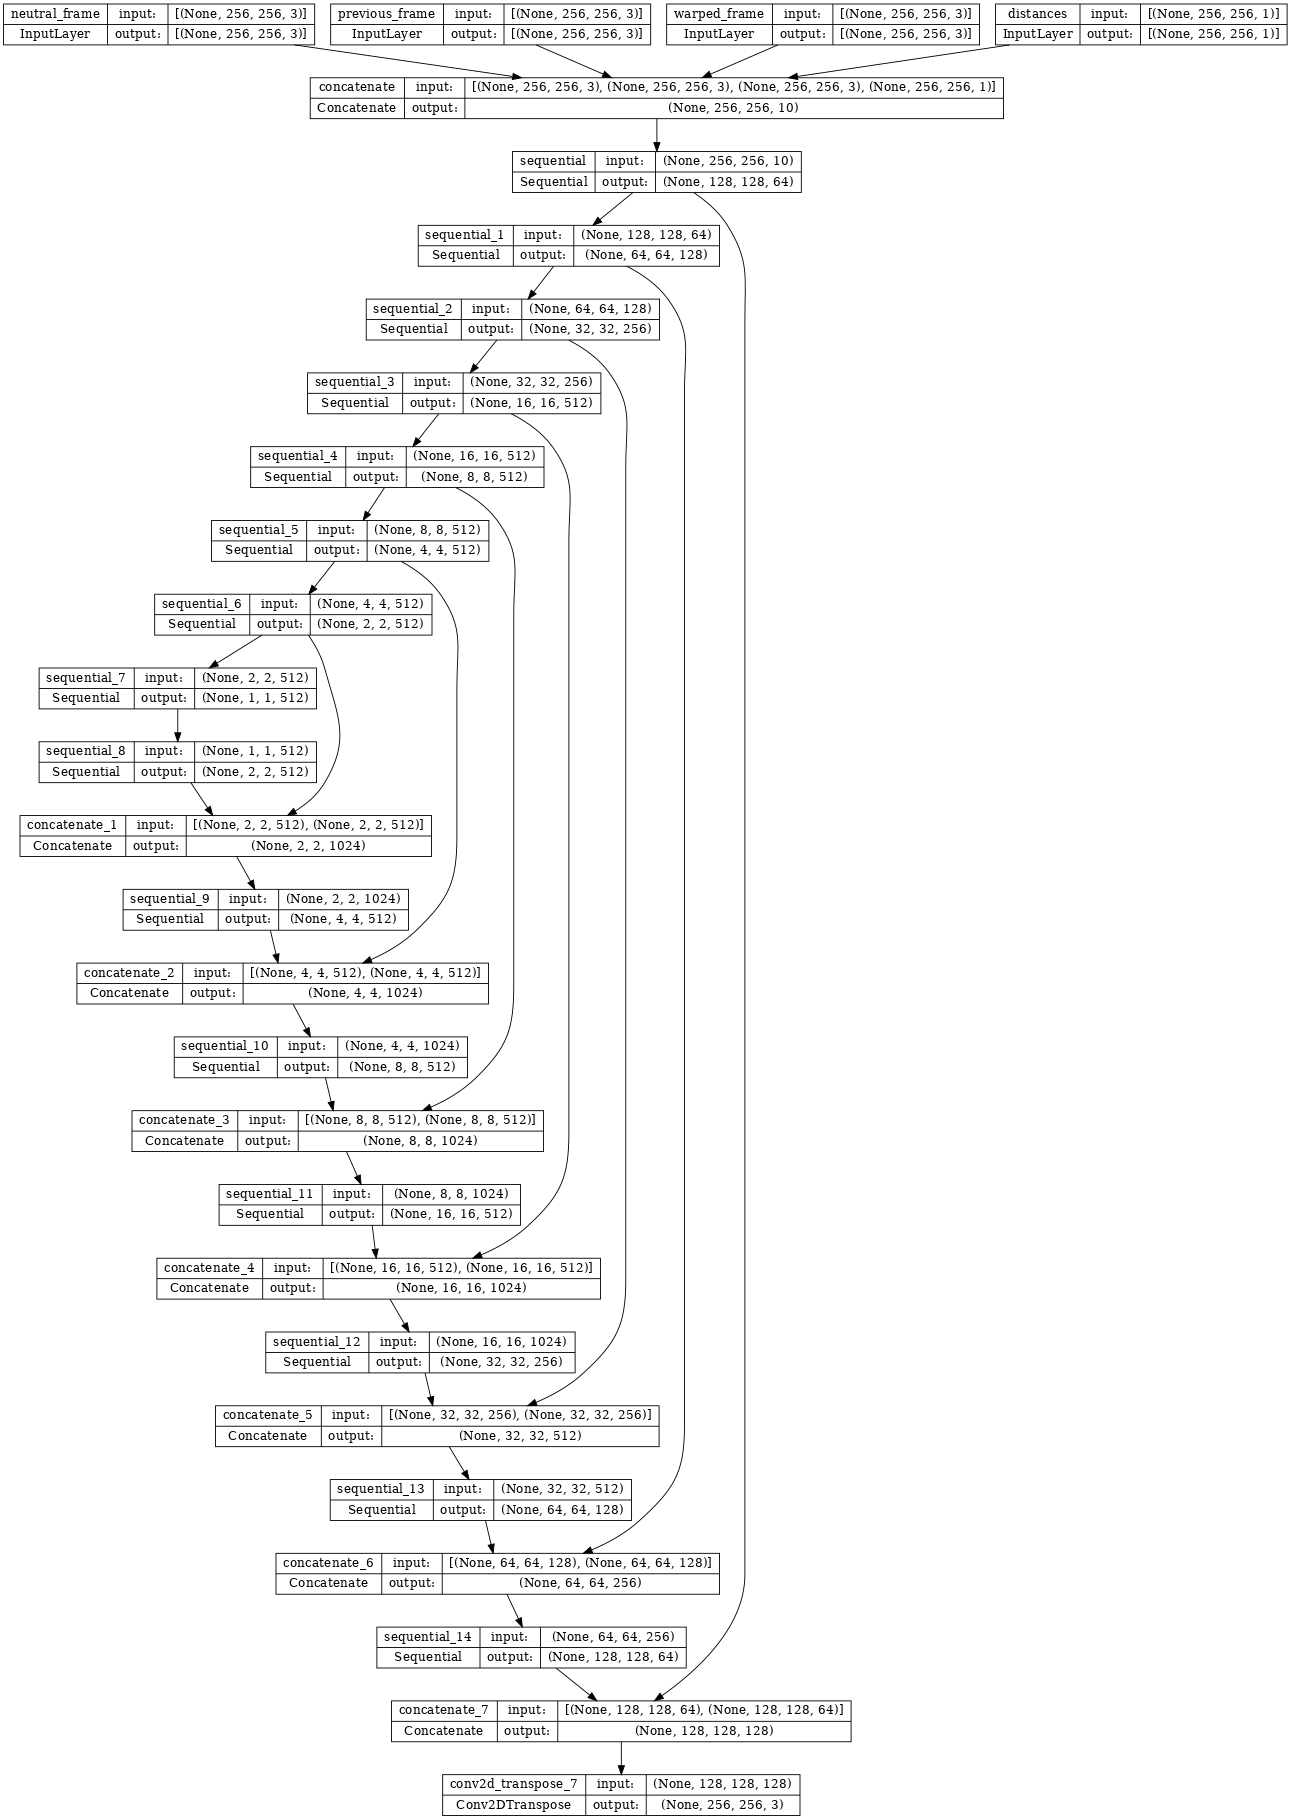

In [10]:
generator = get_generator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'generator.png'))

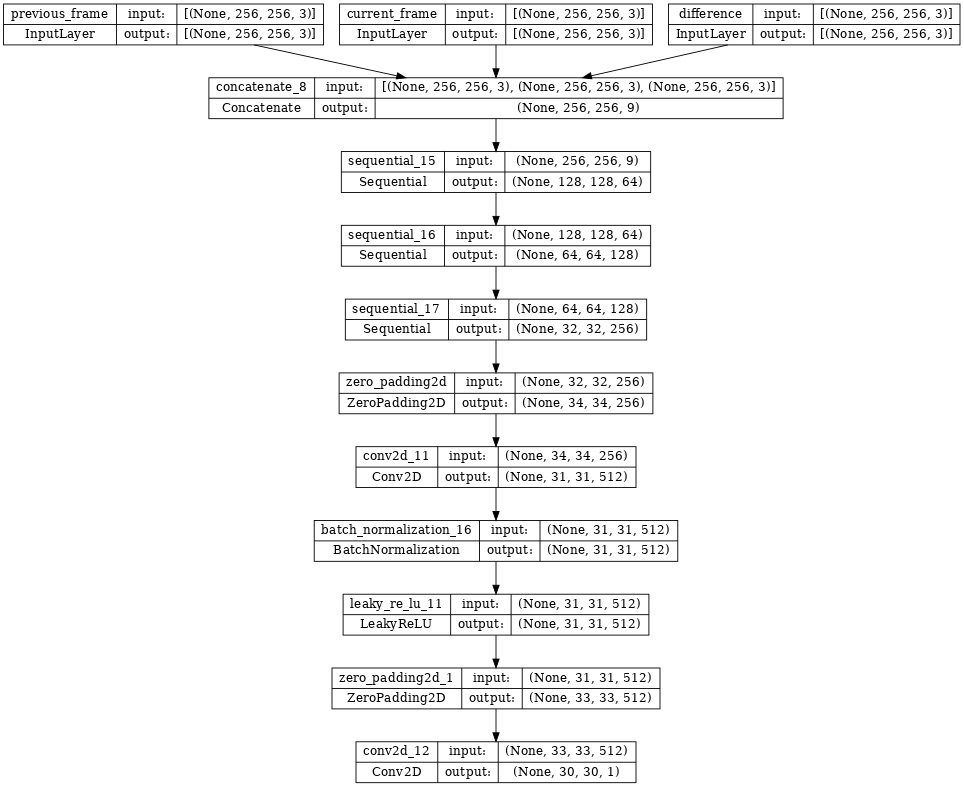

In [11]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'discriminator.png'))

In [12]:
generator_loss = GeneratorLoss(
    # target predicted loss
    target_predicted_function=TARGET_PREDICTED_LOSS,
    lambda_target_predicted=LAMBDA_TARGET_PREDICTED_LOSS,
    # coherence loss
    coherence_loss_function=COHERENCE_LOSS,
    lambda_coherence_loss=LAMBDA_COHERENCE_LOSS,
    # landmarks loss
    landmarks_loss_function=LANDMARKS_LOSS,
    lambda_landmarks_loss=LAMBDA_LANDMARKS_LOSS,
    # landmarks coherence loss
    landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
    lambda_landmarks_coherence_loss=LAMBDA_LANDMARKS_COHERENCE_LOSS,
    # perceptual loss
    lambda_perceptual_loss=LAMBDA_PERCEPTUAL_LOSS,
    # interpolation frames loss
    interpolation_frames_loss_function=INTERPOLATION_FRAMES_LOSS,
    lambda_interpolation_frames_loss=LAMBDA_INTERPOLATION_FRAMES_LOSS,
    # interpolation landmarks loss
    interpolation_landmarks_loss_function=INTERPOLATION_LANDMARKS_LOSS,
    lambda_interpolation_landmarks_loss=LAMBDA_INTERPOLATION_LANDMARKS_LOSS
)
                    

In [13]:
discriminator_loss = DiscriminatorLoss()

In [14]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [15]:
BASE_DIR = OUPUT_PATH / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [16]:
summary_writer = tf.summary.create_file_writer(str(log_file))

In [17]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % DISPLAY_EACH_STEPS == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch()
        plot_results(samples_target, previously_generated, generated_frames)

      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_losses = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          for name, value in gen_losses.items():
            tf.summary.scalar(f'gen_{name}', value, step=step)
      
      if (step + 1) % SAVING_EACH_STEPS == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

  0%|          | 0/20000 [00:00<?, ?it/s]

2023-10-18 16:19:00.185969: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2023-10-18 16:19:01.071835: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.67GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-10-18 16:19:01.162371: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.35GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Input Sequence


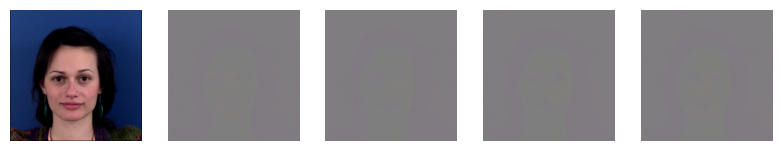

Ground Truth


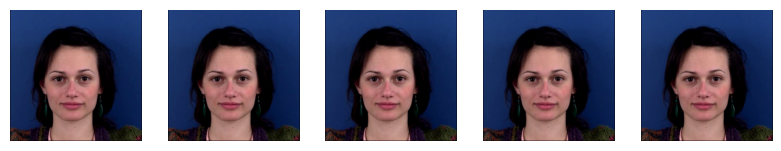

Predicted Sequence


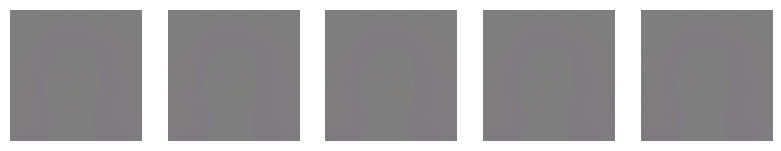

2023-10-18 16:19:05.761239: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.17GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-10-18 16:19:06.130368: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-10-18 16:19:06.314984: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.19GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2023-10-18 16:19:10.638099: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU

2023-10-18 16:19:25.840376: W tensorflow/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 512.0KiB (rounded to 524288)requested by op Conv2DBackpropInput
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2023-10-18 16:19:25.840487: I tensorflow/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2023-10-18 16:19:25.840509: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 138, Chunks in use: 138. 34.5KiB allocated for chunks. 34.5KiB in use in bin. 5.9KiB client-requested in use in bin.
2023-10-18 16:19:25.840525: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 55, Chunks in use: 55. 27.5KiB allocated for chunks. 27.5KiB in use in bin. 27.5KiB client-requested in use in bin.
2023-10-18 16:19:25.840540: I tensorflow/ts

ResourceExhaustedError: {{function_node __wrapped__Conv2DBackpropInput_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[128,4,4,64] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:Conv2DBackpropInput] name: 

In [18]:
if TRAIN:
    tf.profiler.experimental.start(str(log_dir))
    train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    fit(train_generator, test_generator, steps=STEPS)

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

ls: cannot access '../app/output/b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100/training_checkpoints': No such file or directory


In [ ]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

Input Sequence


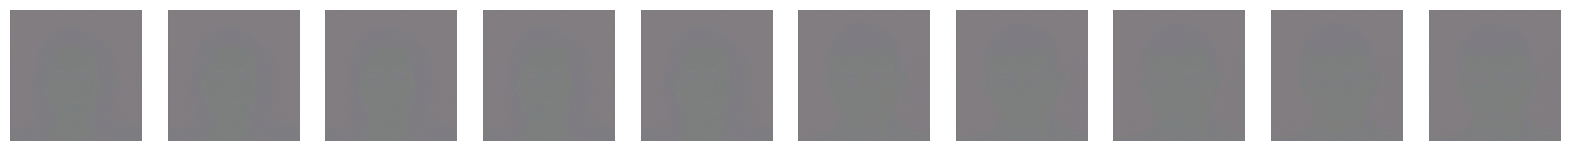

Ground Truth


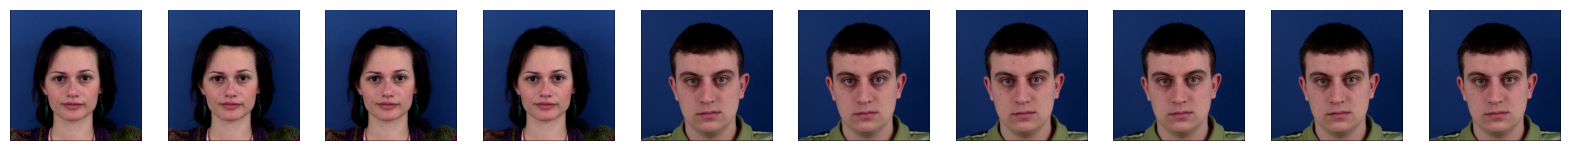

Predicted Sequence


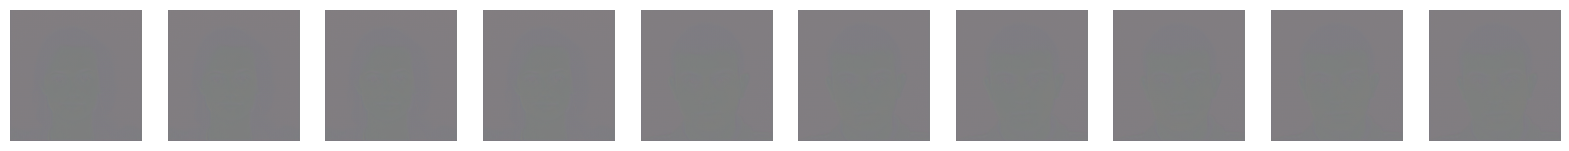

In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
for i in range(0,10):
  previously_generated, generated_frames, samples_target = test_generator.generate_next_batch()
  clear_output(wait=True)
  plot_results(samples_target, previously_generated, generated_frames)

In [ ]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    # fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        # "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_next_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

In [ ]:
if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

  7%|7         | 3030/42000 [02:46<38:00, 17.09it/s]

SSIM    0.277263
PSNR    9.542814
MSE     0.454667
L1      0.597156
ACD     0.000436
dtype: float64
SSIM    0.050161
PSNR    0.768625
MSE     0.092151
L1      0.078403
ACD     0.000303
dtype: float64


KeyboardInterrupt: 

In [ ]:
if TEST:
    print(df)

          SSIM       PSNR       MSE        L1       ACD
0     0.865694  31.420923  0.002858  0.027978  0.000414
1     0.854436  30.706421  0.003404  0.030615  0.001362
2     0.830304  27.862946  0.006543  0.039940  0.000400
3     0.816946  27.108576  0.007691  0.043561  0.000183
4     0.816414  27.256384  0.007452  0.043077  0.000003
...        ...        ...       ...       ...       ...
4201  0.826506  30.011074  0.003949  0.038918  0.000632
4202  0.841465  31.303394  0.002977  0.033897  0.000072
4203  0.840269  31.514502  0.002788  0.032681  0.001546
4204  0.837769  31.643948  0.002704  0.032609  0.000048
4205  0.875850  31.949146  0.002529  0.028626  0.000427

[4206 rows x 5 columns]


In [ ]:
if TEST:
    print(df.mean())

SSIM     0.814063
PSNR    27.746426
MSE      0.009036
L1       0.046664
ACD      0.000410
dtype: float64


In [ ]:
if TEST:
    print(df.std())

SSIM    0.060150
PSNR    2.984801
MSE     0.010172
L1      0.018782
ACD     0.000311
dtype: float64


# coherence measures

In [ ]:
def compute_scores_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/diff_metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_diff_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
    scores_path = f"{log_dir}/diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

42060it [1:01:14,  2.47it/s]

SSIM     0.923620
PSNR    37.628269
MSE      0.001832
L1       0.014096
ACD      0.000407
dtype: float64
SSIM    0.034817
PSNR    2.753297
MSE     0.003793
L1      0.008168
ACD     0.000307
dtype: float64


In [ ]:
if TEST:
    print(df.mean())

SSIM     0.923620
PSNR    37.628269
MSE      0.001832
L1       0.014096
ACD      0.000407
dtype: float64


In [ ]:
if TEST:
    print(df.std())

SSIM    0.034817
PSNR    2.753297
MSE     0.003793
L1      0.008168
ACD     0.000307
dtype: float64


# Plot some images

In [ ]:
if PLOT:
  test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
  for i in range(0,10):
    clear_output(wait=True)
    test_generator.next_plot()

# Save videos gifs

In [ ]:
from data_generator import PreprocessedDataGenerator
if SAVE_GIFS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                test_generator.save_next_video()
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break

# Test per video

In [ ]:
def compute_scores_video():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/video_metrics.csv")
                if "path_id" in df.columns:
                    print(df.drop(columns=["path_id"], inplace=False).mean())
                    print(df.drop(columns=["path_id"], inplace=False).std())
                current_frames, generated_frames, path_id = test_generator.generate_next_video()
                if current_frames is not None and generated_frames is not None:
                    video_size = generated_frames.shape[1]
                    s = evaluate_metrics(current_frames, generated_frames, batch_size=video_size)
                    s["path_id"] = path_id
                    scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

In [ ]:
if TEST_VIDEO:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/video_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_video()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).mean())

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).std())

In [ ]:
def compute_video_scores_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/video_diff_metrics.csv")
                if "path_id" in df.columns:
                    print(df.drop(columns=["path_id"], inplace=False).mean())
                    print(df.drop(columns=["path_id"], inplace=False).std())
                current_frames, generated_frames, path_id = test_generator.generate_diff_video()
                if current_frames is not None and generated_frames is not None:
                    video_size = generated_frames.shape[1]
                    s = evaluate_metrics(current_frames, generated_frames, batch_size=video_size)
                    s["path_id"] = path_id
                    scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_VIDEO:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
    scores_path = f"{log_dir}/video_diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_video_scores_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).mean())

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).std())